# hw2: Решающие деревья

*Спасибо великому курсу великого Евгения Соколова*

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплементацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

Все данные, на которых будут обучаться модели, вы можете найти на диске.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов. Неэффективная и/или неоригинальная реализация кода может негативно отразиться на оценке.

### Формат сдачи
Заполненный ноутбук ```hw2-trees.ipynb``` и модуль с реализованными функциями и классами ```hw2code.py``` необходимо загрузить на свой Github. Затем нужно оставить комментарий в Google-таблице с оценками в столбце <<hw2>> в строке со своей фамилией о том, что вы выполнили работу с указанием ника на Kaggle.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [15]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
                        n_redundant=0, )
]

In [16]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

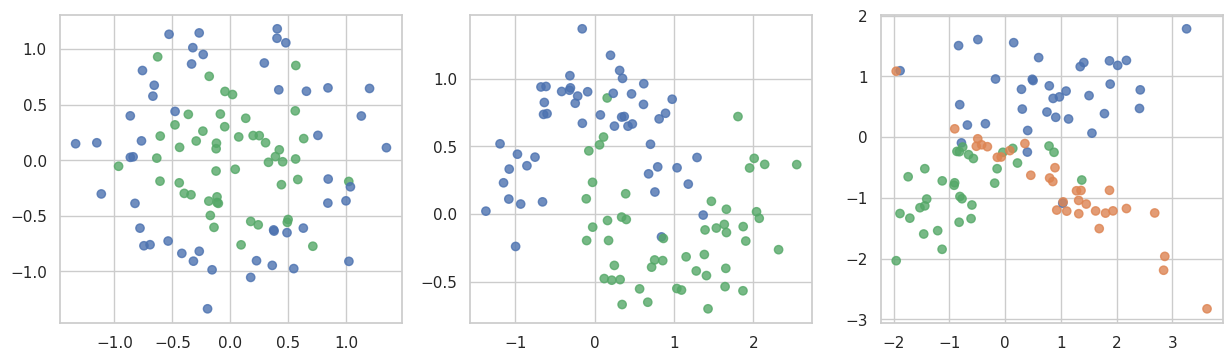

In [17]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__Задание 1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [18]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

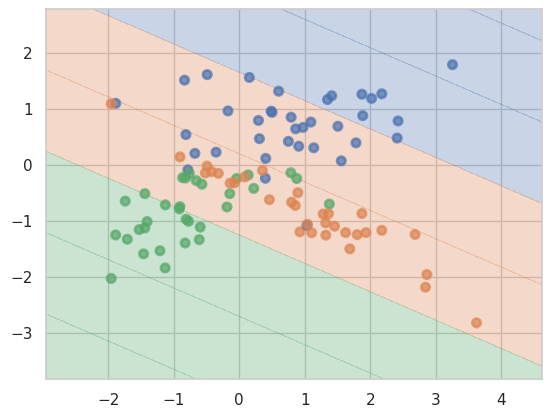

In [19]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Circles:
  Accuracy на обучающей выборке: 1.0000
  Accuracy на тестовой выборке: 0.8400
  Разница, переобучение: 0.1600

Moons:
  Accuracy на обучающей выборке: 1.0000
  Accuracy на тестовой выборке: 0.9600
  Разница, переобучение: 0.0400

Classification:
  Accuracy на обучающей выборке: 1.0000
  Accuracy на тестовой выборке: 0.8400
  Разница, переобучение: 0.1600



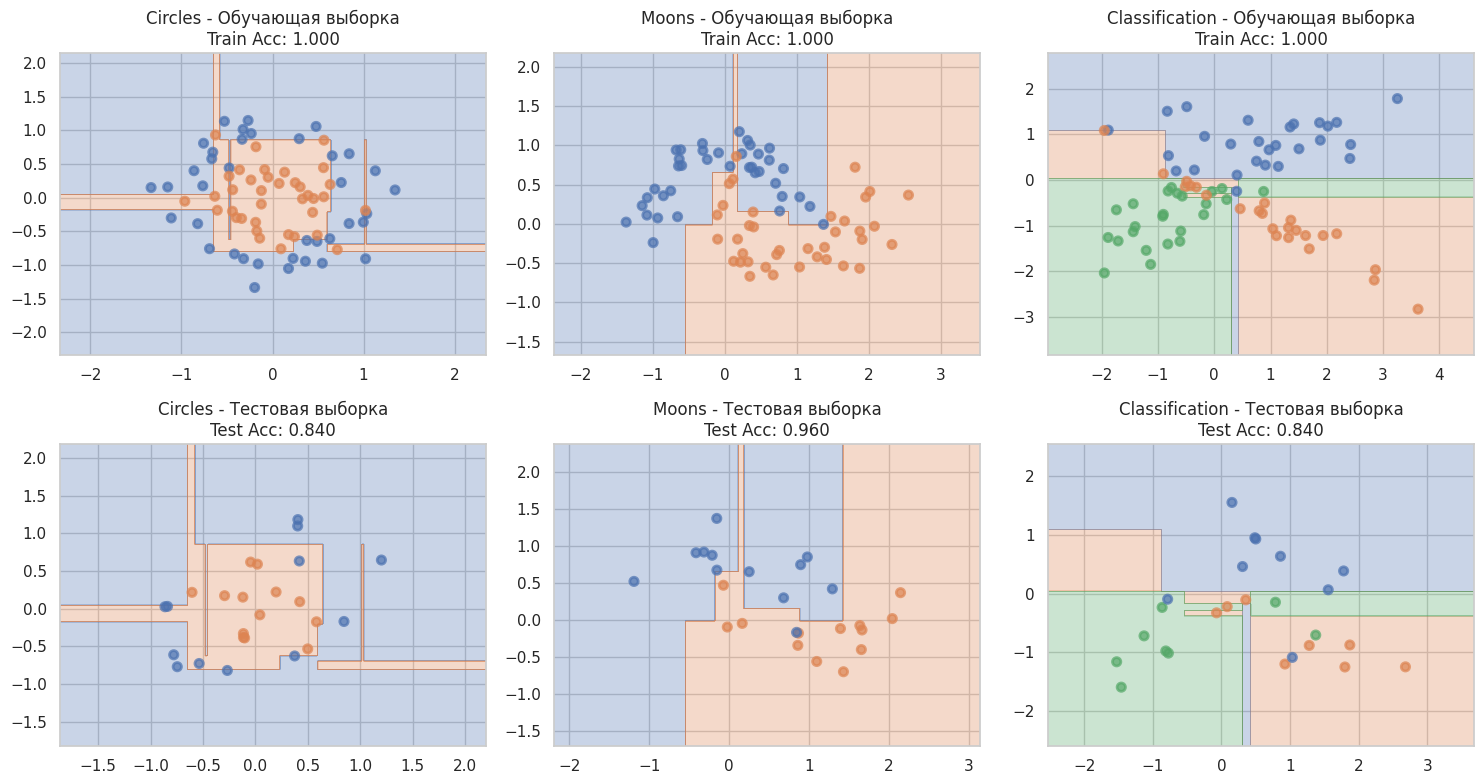

In [20]:
from sklearn.metrics import accuracy_score

names = ['Circles', 'Moons', 'Classification']
plt.figure(figsize=(15, 8))

for i, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                        random_state=32, stratify=y)

    tree = DecisionTreeClassifier(random_state=32)
    tree.fit(X_train, y_train)

    y_train_pred = tree.predict(X_train)
    y_test_pred = tree.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"{names[i]}:")
    print(f"  Accuracy на обучающей выборке: {train_accuracy:.4f}")
    print(f"  Accuracy на тестовой выборке: {test_accuracy:.4f}")
    print(f"  Разница, переобучение: {train_accuracy - test_accuracy:.4f}")
    print()

    plt.subplot(2, 3, i + 1)
    plot_surface(tree, X_train, y_train)
    plt.title(f'{names[i]} - Обучающая выборка\nTrain Acc: {train_accuracy:.3f}')

    plt.subplot(2, 3, i + 4)
    plot_surface(tree, X_test, y_test)
    plt.title(f'{names[i]} - Тестовая выборка\nTest Acc: {test_accuracy:.3f}')

plt.tight_layout()
plt.show()

__Ответ:__

Деревья на Circles и Classification показали сильное переобучение. Дерево Moons тоже, но в меньшей мере.

__Задание 2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

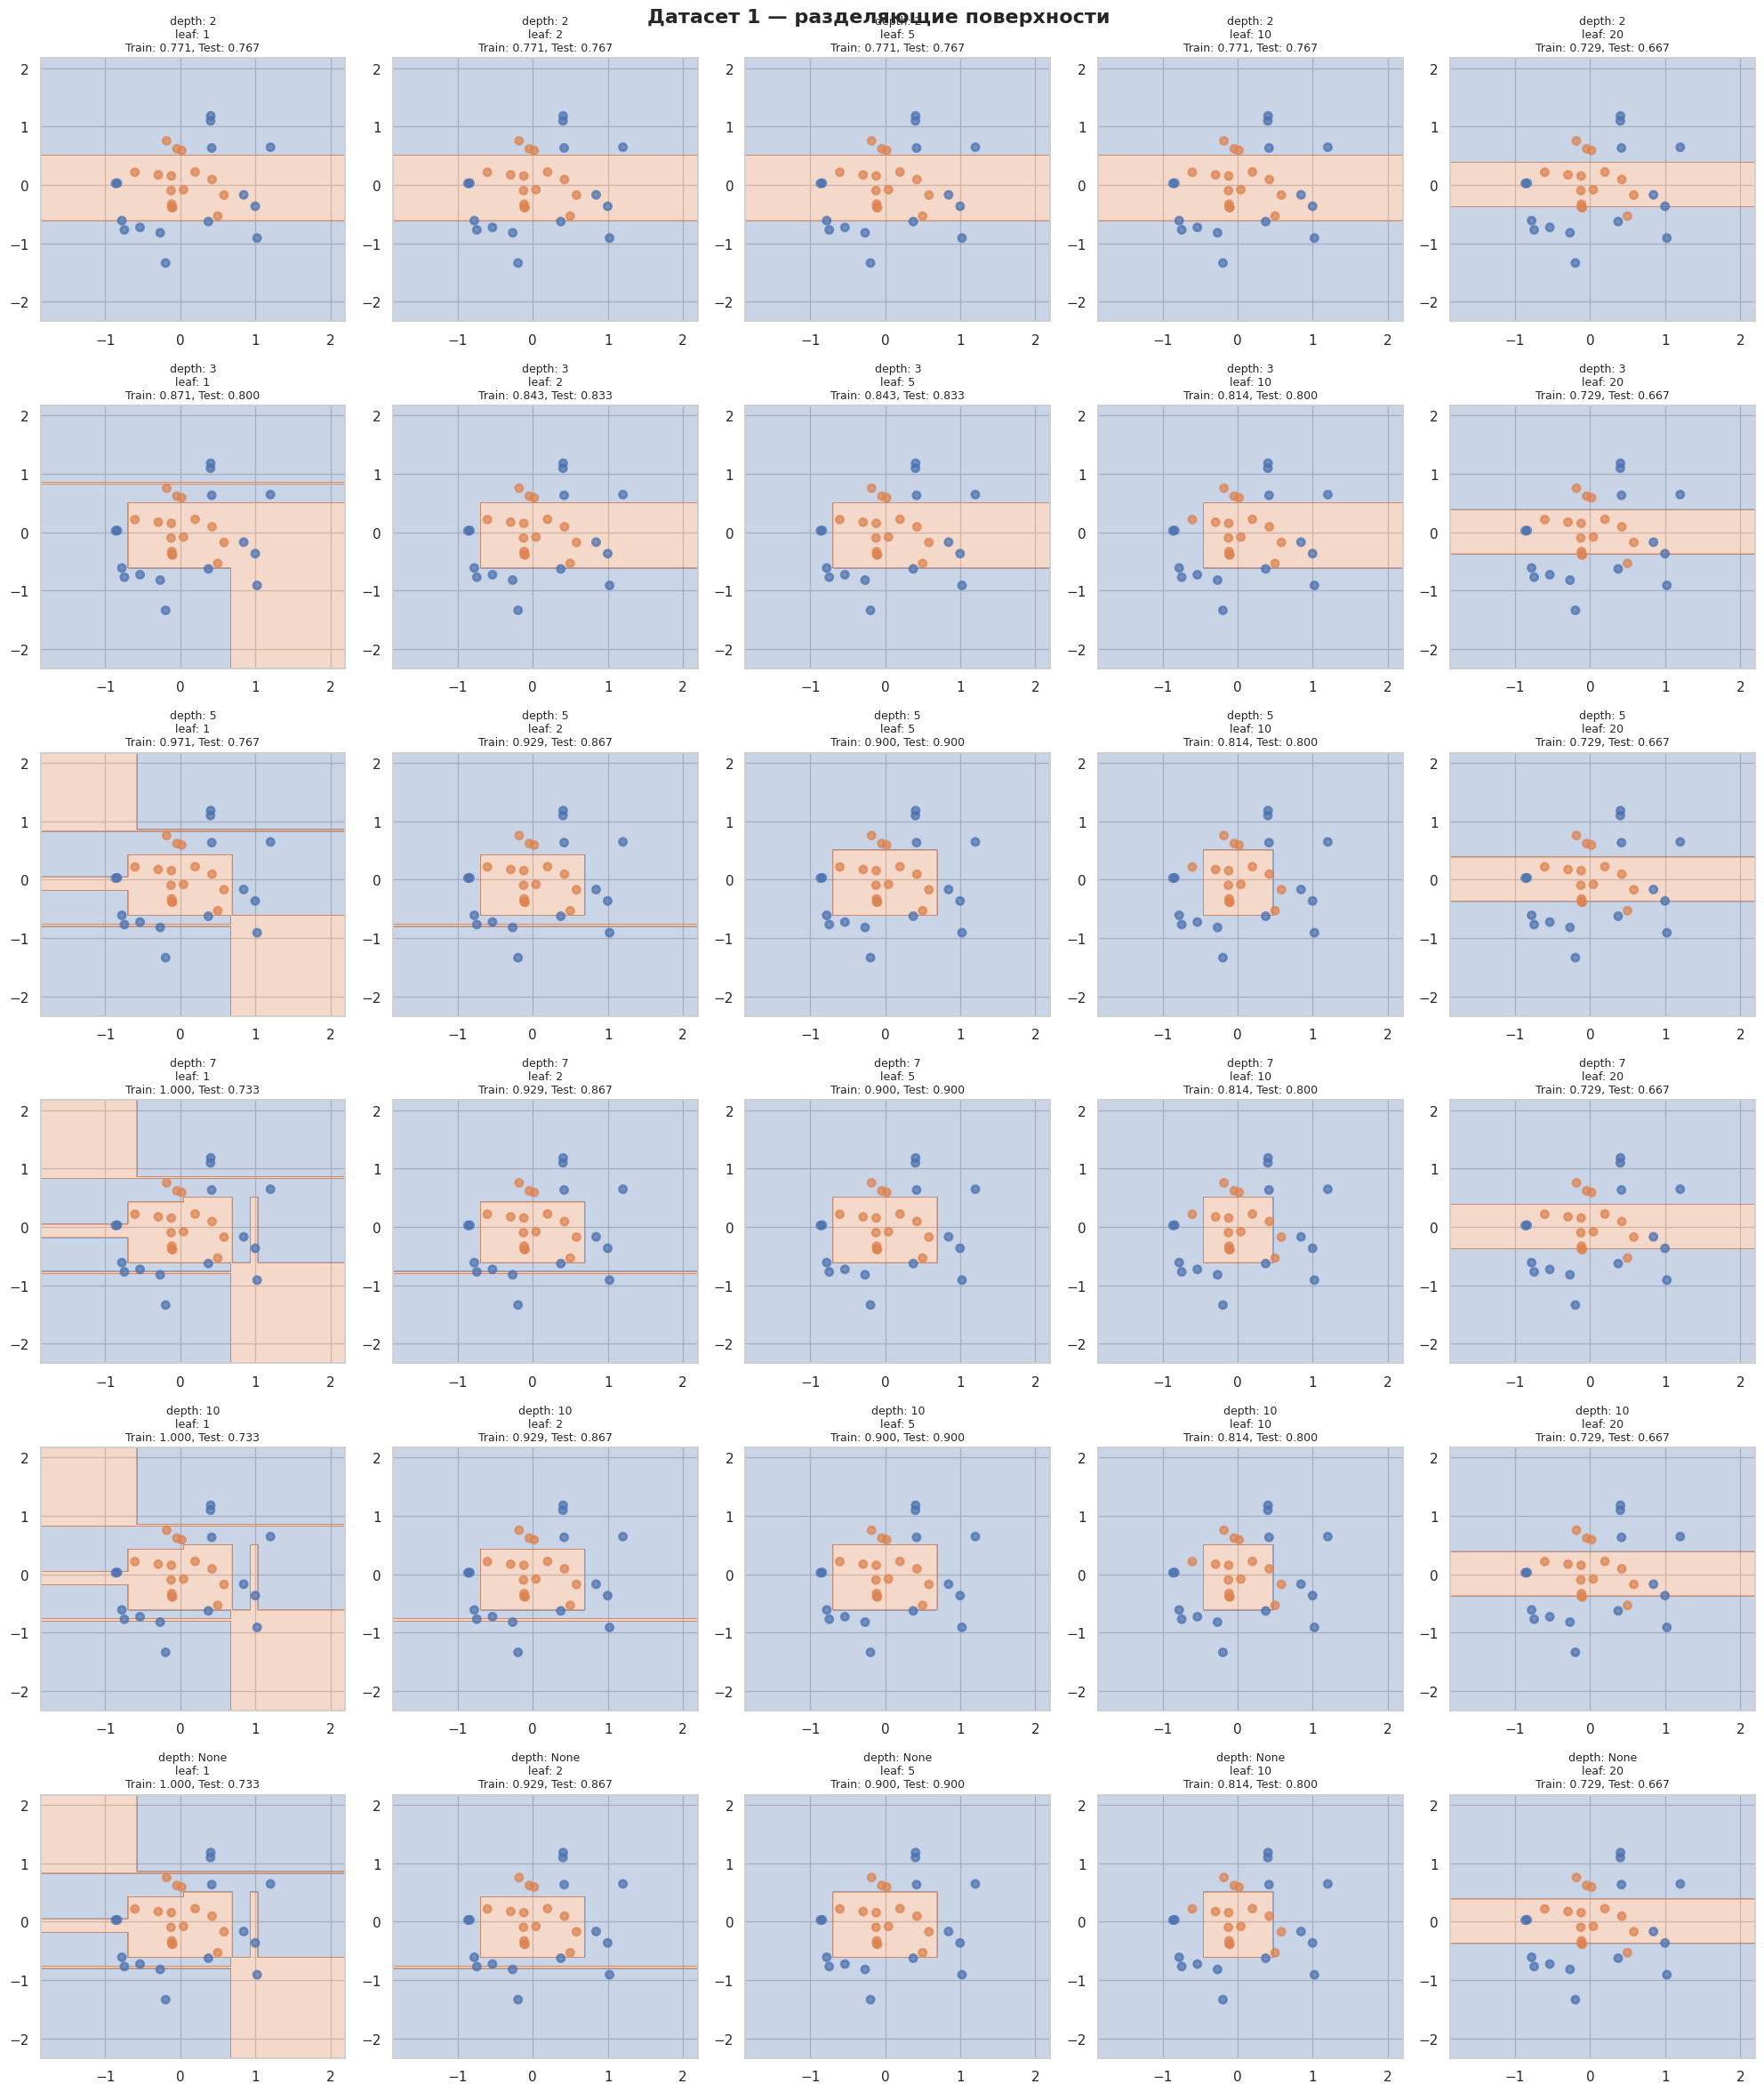

,max_depth,min_samples_leaf,train_acc,test_acc,gap
0,2,1,0.771,0.767,0.005
1,2,2,0.771,0.767,0.005
2,2,5,0.771,0.767,0.005
3,2,10,0.771,0.767,0.005
4,2,20,0.729,0.667,0.062
5,3,1,0.871,0.800,0.071
6,3,2,0.843,0.833,0.010
7,3,5,0.843,0.833,0.010
8,3,10,0.814,0.800,0.014
9,3,20,0.729,0.667,0.062



ANALYSIS:
 Best test accuracy: 0.900 при max_depth=5, min_samples_leaf=5
 Train acc: 0.900; Overfit gap = 0.000
 Худшее переобучение: gap=0.267 при depth=7, leaf=1

ВЫВОД:
 Dataset 1 (Circles): сложная нелинейная граница. Хорошая test-accuracy достигается при достаточной глубине,
---------------------------------------------------------------------- 



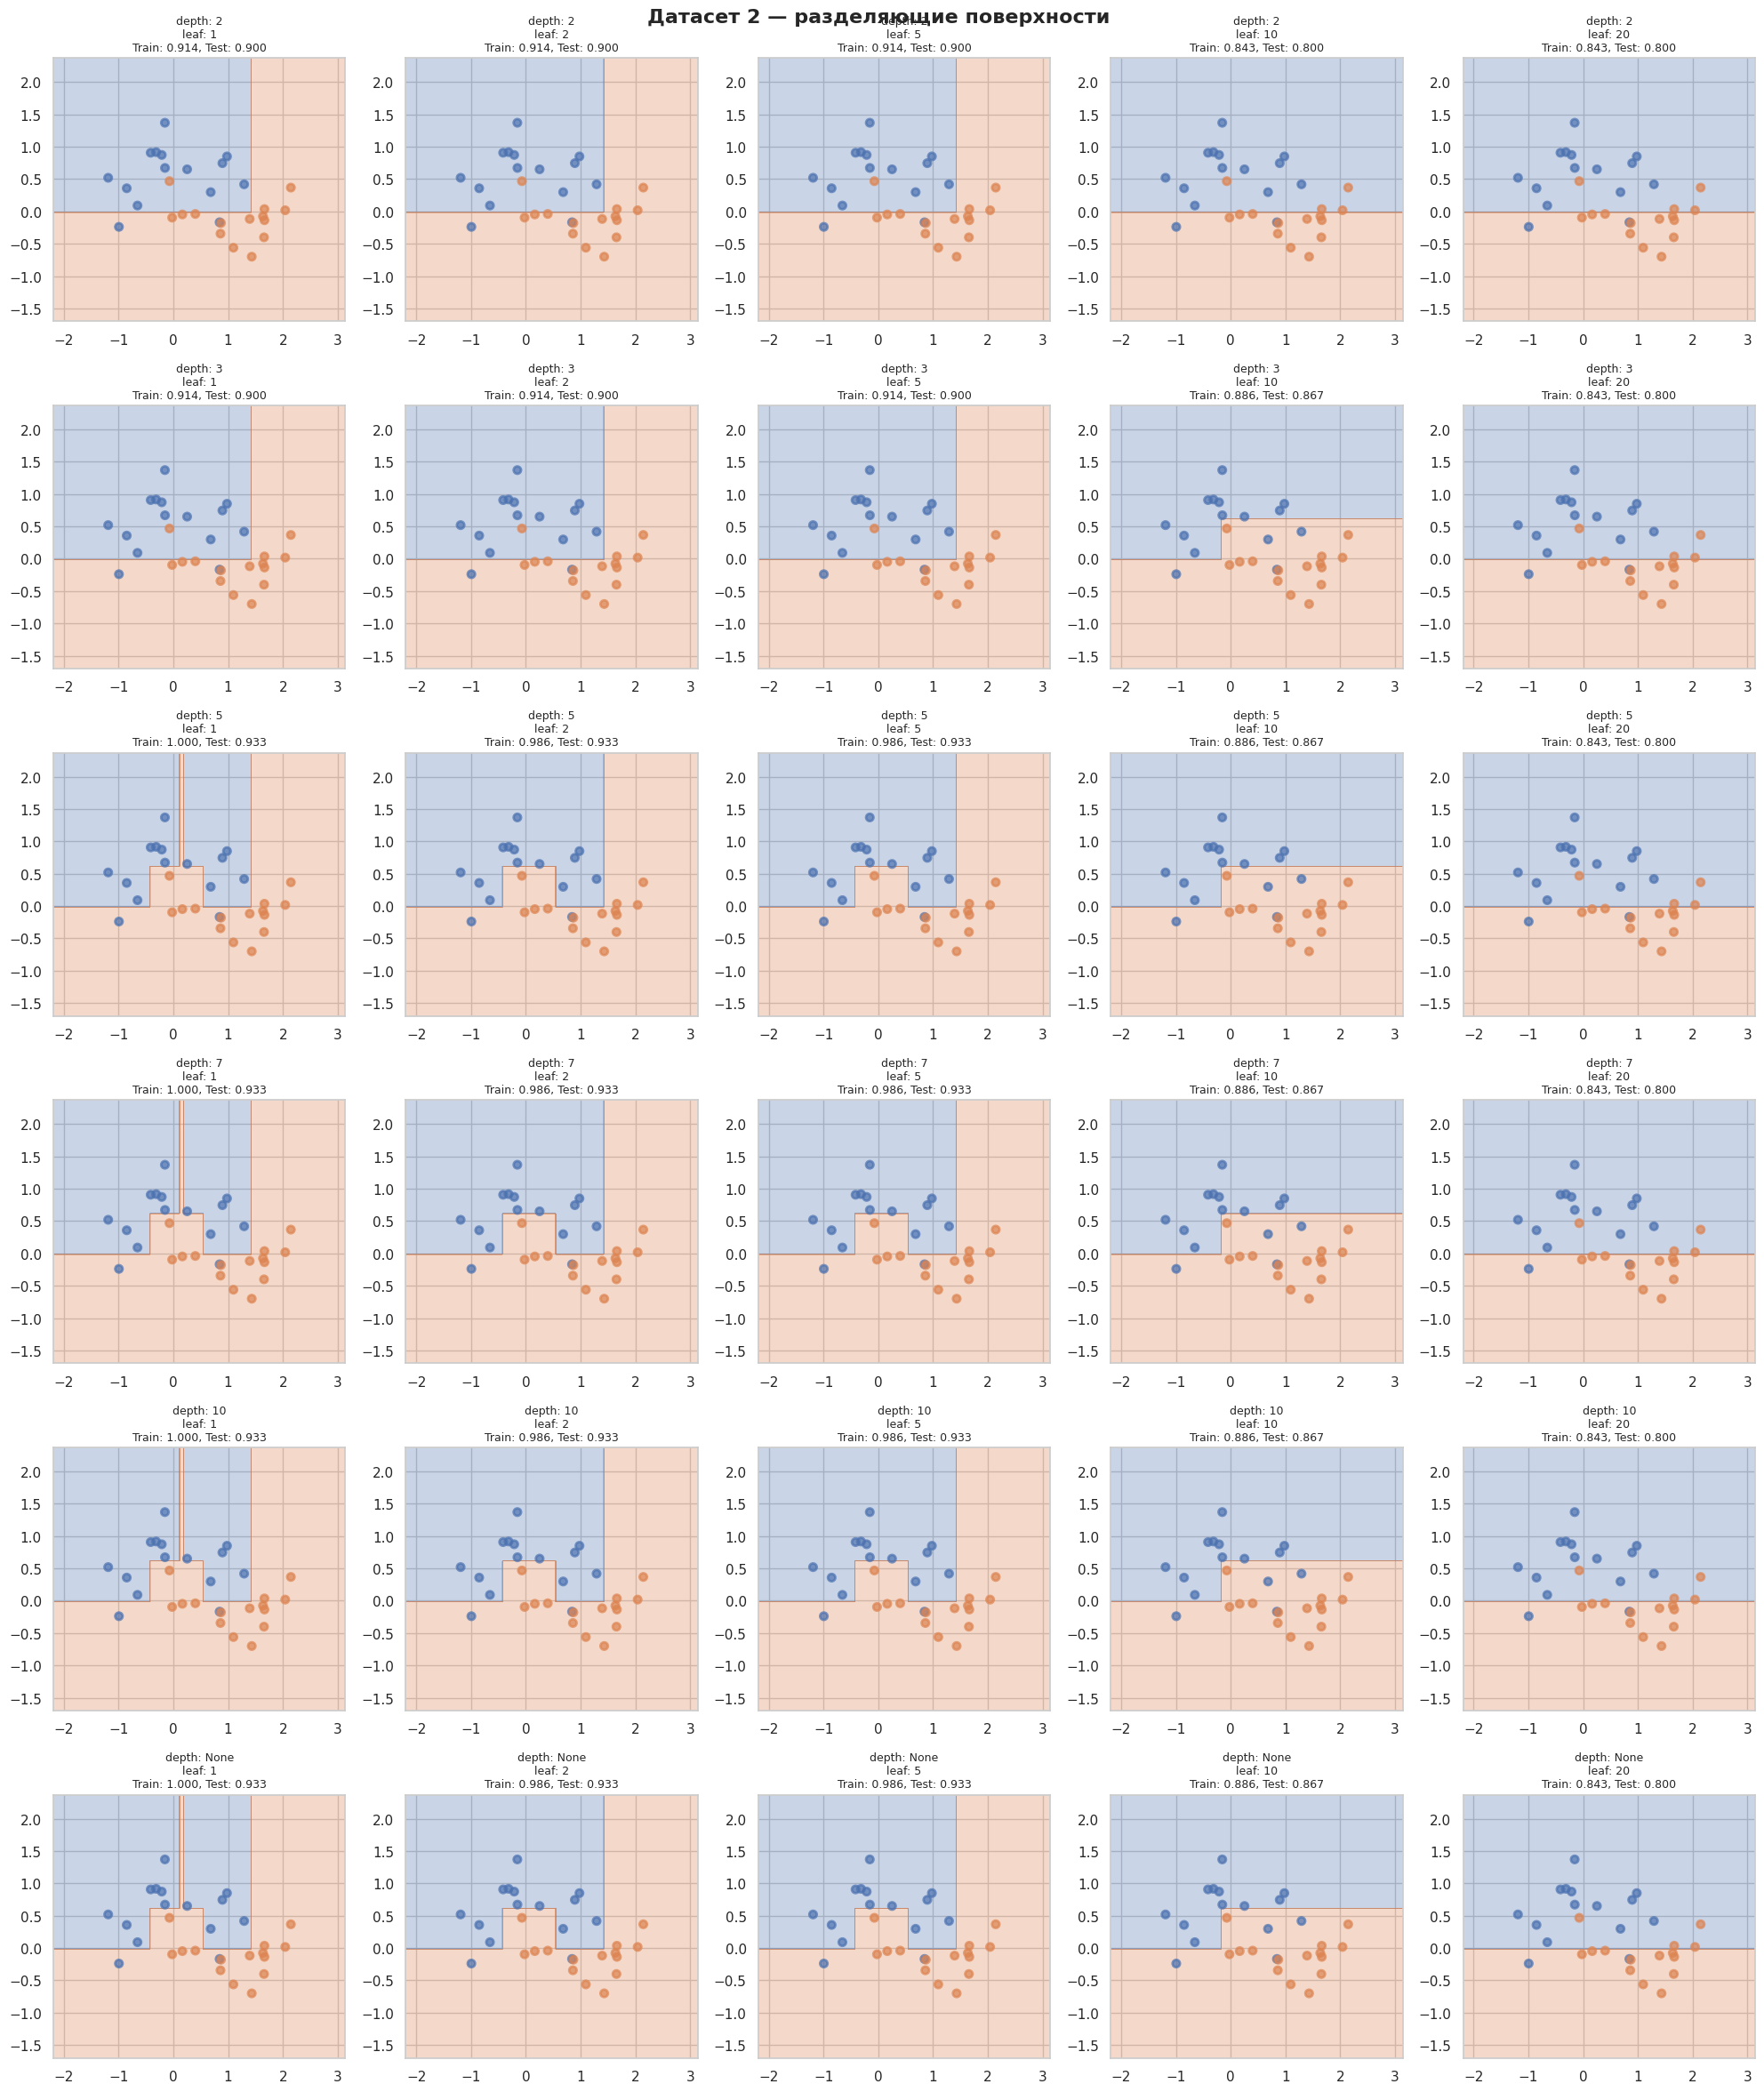

,max_depth,min_samples_leaf,train_acc,test_acc,gap
0,2,1,0.914,0.900,0.014
1,2,2,0.914,0.900,0.014
2,2,5,0.914,0.900,0.014
3,2,10,0.843,0.800,0.043
4,2,20,0.843,0.800,0.043
5,3,1,0.914,0.900,0.014
6,3,2,0.914,0.900,0.014
7,3,5,0.914,0.900,0.014
8,3,10,0.886,0.867,0.019
9,3,20,0.843,0.800,0.043



ANALYSIS:
 Best test accuracy: 0.933 при max_depth=5, min_samples_leaf=1
 Train acc: 1.000; Overfit gap = 0.067
 Худшее переобучение: gap=0.067 при depth=5, leaf=1

ВЫВОД:
 Dataset 2 (Moons): полумесяцеобразная структура. Небольшая глубина часто достаточна; сильное увеличение depth
---------------------------------------------------------------------- 



In [ ]:
sns.set(style='whitegrid')

max_depths = [2, 3, 5, 7, 10, None]
min_samples_leaves = [1, 2, 5, 10, 20]

TEST_SIZE = 0.3
RANDOM_STATE = 32

show_train_matrix_side_by_side = False

for ds_idx, (X, y) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y if len(np.unique(y)) > 1 else None)

    n_rows = len(max_depths)
    n_cols = len(min_samples_leaves)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), squeeze=False)
    fig.suptitle(f'Датасет {ds_idx+1} — разделяющие поверхности ', fontsize=16, fontweight='bold')

    train_scores = np.zeros((n_rows, n_cols))
    test_scores = np.zeros((n_rows, n_cols))
    gap_scores = np.zeros((n_rows, n_cols))

    for i, md in enumerate(max_depths):
        for j, leaf in enumerate(min_samples_leaves):
            tree = DecisionTreeClassifier(max_depth=md, min_samples_leaf=leaf, random_state=RANDOM_STATE)
            tree.fit(X_train, y_train)

            train_acc_sc = accuracy_score(y_train, tree.predict(X_train))
            test_acc_sc = accuracy_score(y_test, tree.predict(X_test))

            train_scores[i, j] = train_acc_sc
            test_scores[i, j] = test_acc_sc
            gap_scores[i, j] = train_acc_sc - test_acc_sc

            ax = axes[i][j]
            plt.sca(ax)
            plot_surface(tree, X_test, y_test)

            depth_label = 'None' if md is None else md
            ax.set_title(f'depth: {depth_label}\nleaf: {leaf}\nTrain: {train_acc_sc:.3f}, Test: {test_acc_sc:.3f}',
                         fontsize=9)
    plt.tight_layout()
    plt.show()

    rows = []
    for i, md in enumerate(max_depths):
        for j, leaf in enumerate(min_samples_leaves):
            rows.append({
                'max_depth': 'None' if md is None else md,
                'min_samples_leaf': leaf,
                'train_acc': round(float(train_scores[i, j]), 3),
                'test_acc': round(float(test_scores[i, j]), 3),
                'gap': round(float(gap_scores[i, j]), 3)
            })
    df = pd.DataFrame(rows)
    display(df)

    best_idx = np.unravel_index(np.nanargmax(test_scores), test_scores.shape)
    worst_overfit_idx = np.unravel_index(np.nanargmax(gap_scores), gap_scores.shape)
    best_md = max_depths[best_idx[0]]
    best_leaf = min_samples_leaves[best_idx[1]]
    print("\nANALYSIS:")
    print(f" Best test accuracy: {test_scores[best_idx]:.3f} при max_depth={best_md}, min_samples_leaf={best_leaf}")
    print(f" Train acc: {train_scores[best_idx]:.3f}; Overfit gap = {gap_scores[best_idx]:.3f}")
    print(f" Худшее переобучение: gap={gap_scores[worst_overfit_idx]:.3f} при depth={max_depths[worst_overfit_idx[0]]}, leaf={min_samples_leaves[worst_overfit_idx[1]]}")

    print("\nВЫВОД:")
    if ds_idx == 0:
        print(" Dataset 1 (Circles): сложная нелинейная граница. Хорошая test-accuracy достигается при достаточной глубине,")
    elif ds_idx == 1:
        print(" Dataset 2 (Moons): полумесяцеобразная структура. Небольшая глубина часто достаточна; сильное увеличение depth")
    else:
        print(" Dataset 3: средняя сложность — оптимум достигается при балансе depth и min_samples_leaf.")
    print("-" * 70, "\n")

__Ответ:__

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__Задание 3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw2code.py

In [1]:
from google.colab import files

uploaded = files.upload()

Saving hw2code.py to hw2code.py
Saving agaricus-lepiota.names to agaricus-lepiota.names
Saving tic-tac-toe-endgame.csv to tic-tac-toe-endgame.csv
Saving agaricus-lepiota.data to agaricus-lepiota.data
Saving students.csv to students.csv


__Задание 4. (0.5 балла)__

Загрузите таблицу students.csv (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

    STG   SCG   STR   LPR   PEG  UNS
0  0.00  0.00  0.00  0.00  0.00    0
1  0.08  0.08  0.10  0.24  0.90    1
2  0.06  0.06  0.05  0.25  0.33    0
3  0.10  0.10  0.15  0.65  0.30    1
4  0.08  0.08  0.08  0.98  0.24    0
(258, 6)
Признаки: ['STG', 'SCG', 'STR', 'LPR', 'PEG']
Классы: [0 1]


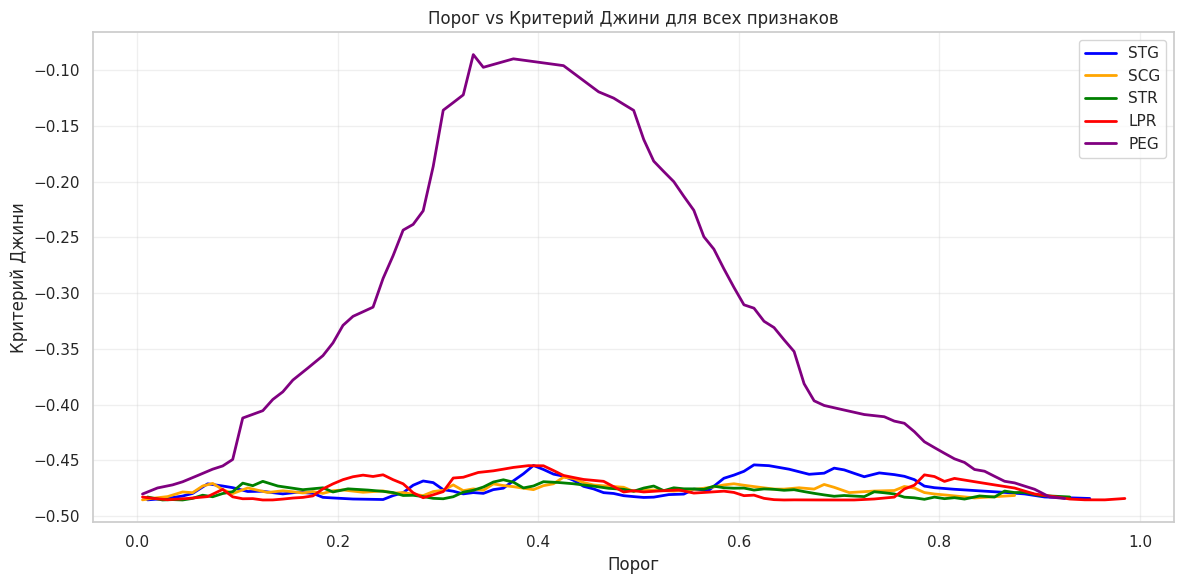

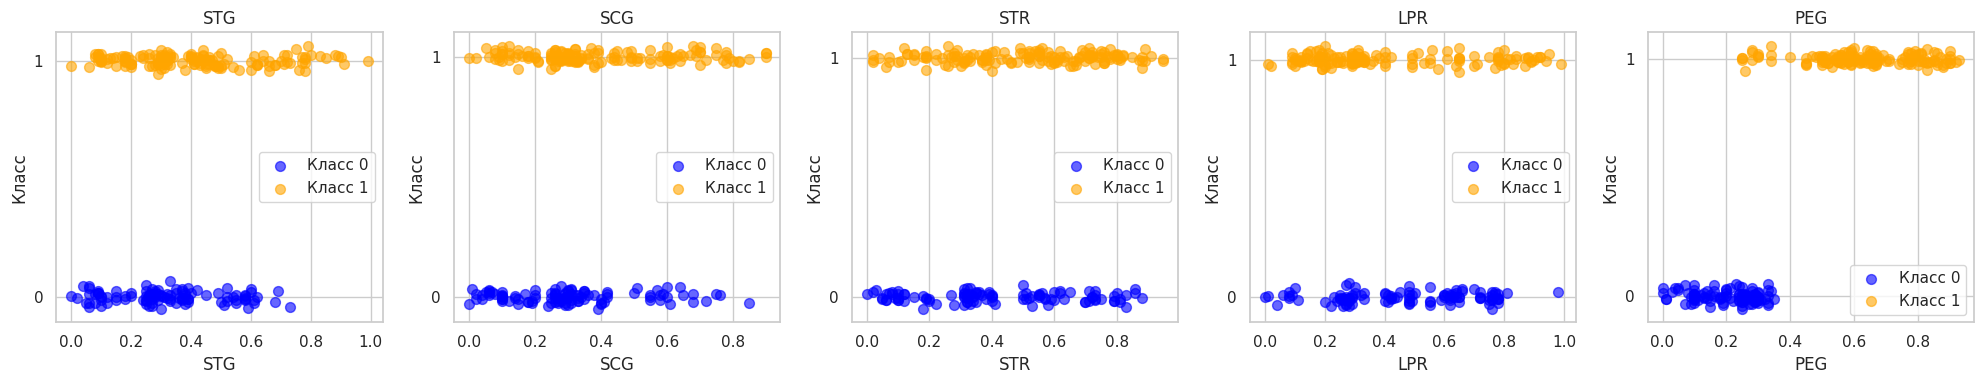

In [4]:
from hw2code import find_best_split


df = pd.read_csv('students.csv')

X = df.iloc[:, :5].values
y = df.iloc[:, -1].values
feature_names = df.columns[:5].tolist()

print(df.head())
print(df.shape)
print("Признаки:", feature_names)
print("Классы:", np.unique(y))

plt.figure(figsize=(12, 6))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for col_idx, feature_name in enumerate(feature_names):
    feature_values = X[:, col_idx]

    thresholds, gini_scores, _, _ = find_best_split(feature_values, y)

    plt.plot(thresholds, gini_scores,
             color=colors[col_idx],
             linewidth=2,
             label=feature_name)

plt.xlabel('Порог')
plt.ylabel('Критерий Джини')
plt.title('Порог vs Критерий Джини для всех признаков')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for col_idx, feature_name in enumerate(feature_names):
    for cls in [0, 1]:
        mask = y == cls
        axes[col_idx].scatter(
            X[mask, col_idx],
            np.ones(np.sum(mask)) * cls + np.random.normal(0, 0.02, np.sum(mask)),
            alpha=0.6,
            label=f'Класс {cls}',
            color=['blue', 'orange'][cls],
            s=50
        )

    axes[col_idx].set_xlabel(feature_name)
    axes[col_idx].set_ylabel('Класс')
    axes[col_idx].set_title(feature_name)
    axes[col_idx].set_yticks([0, 1])
    axes[col_idx].legend()

plt.tight_layout()
plt.show()


__Задание 5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** Признак PEG оказывается наиболее информативным для разделения выборки на два поддерева. Чёткий порог разбиения — около 0.35 — отчётливо прослеживается как на графике зависимости критерия качества (где наблюдается выраженный максимум), так и на scatter-графике (почти все объекты класса 0 расположены слева от порога, а класса 1 — справа).  

У «хороших» признаков кривая имеет ярко выраженный пик, значение которого близко к нулю (в данном контексте — минимальная взвешенная нечистота Джини, или её отрицание). В то же время у «плохих» признаков кривые почти плоские, без резких максимумов, плавные и сосредоточены около –0.5, что свидетельствует об их низкой разделяющей способности.


__Задание 6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw2code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции. Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__Задание 7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (лежит на гитхабе вместе с заданием), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from hw2code import DecisionTree

df = pd.read_csv("agaricus-lepiota.data", header=None)

def tree_depth(node):
    if node["type"] == "terminal":
        return 0
    l  = tree_depth(node["left_child"])
    r = tree_depth(node["right_child"])
    return 1 + max(l, r)


le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

feature_types = ["categorical"] * X.shape[1]
tree = DecisionTree(feature_types)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2f}")

depth = tree_depth(tree._tree)
print(f"Depth: {depth}")



Accuracy: 1.00
Depth: 6


__Задание 8. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

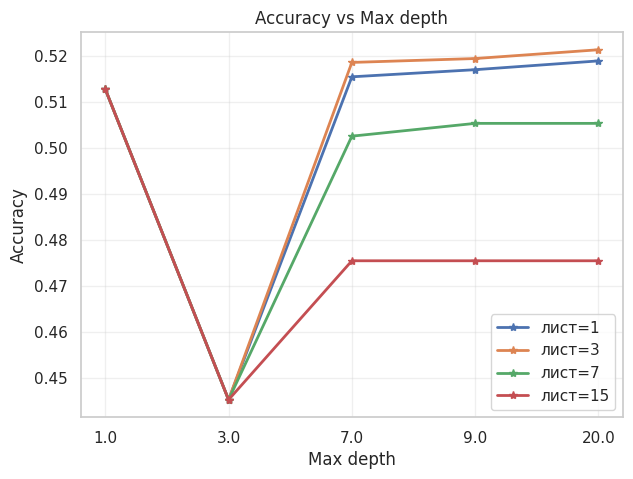

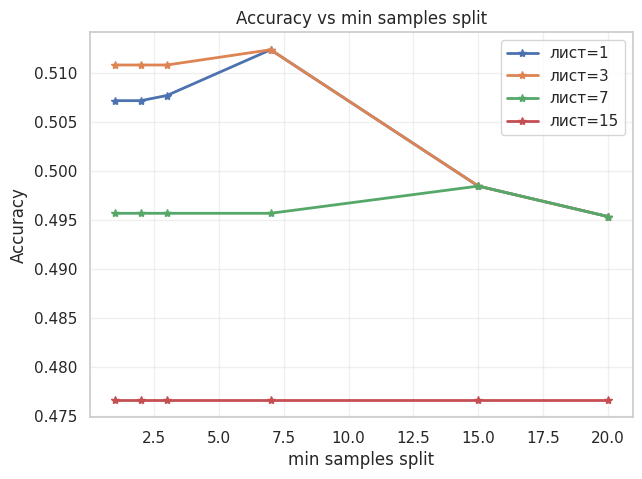

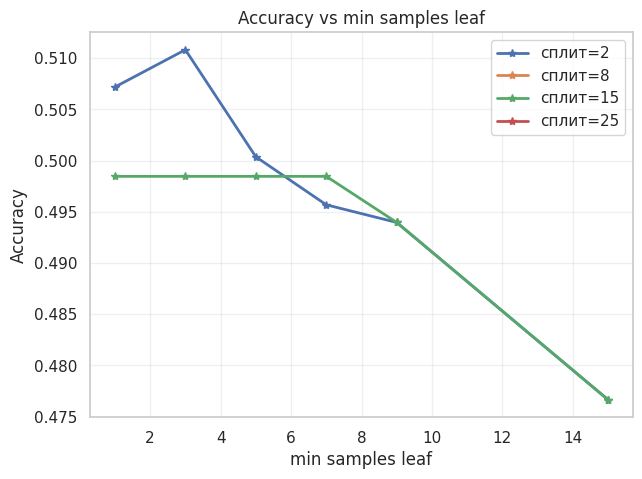

In [9]:
from sklearn.model_selection import cross_val_score

df = pd.read_csv("tic-tac-toe-endgame.csv")

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X = X.apply(LabelEncoder().fit_transform)

enc = LabelEncoder()
y = enc.fit_transform(y)

feature_types = ["categorical"] * X.shape[1]

params = {
    'max_depth': [None, 1, 3, 7, 9, 20],
    'min_samples_split': [1, 2, 3, 7, 15, 20],
    'min_samples_leaf': [1, 3, 5, 7, 9, 15]
}

results = []

for md in params['max_depth']:
    for mss in params['min_samples_split']:
        for msl in params['min_samples_leaf']:
            tree = DecisionTree(feature_types,
                                max_depth=md,
                                min_samples_split=mss,
                                min_samples_leaf=msl)
            scores = cross_val_score(
                tree,
                X.values,
                y,
                cv=5,
                scoring='accuracy'
            )
            results.append({
                'max_depth': md,
                'min_samples_split': mss,
                'min_samples_leaf': msl,
                'accuracy_mean': scores.mean()
            })

res = pd.DataFrame(results)
plt.figure(figsize=(7,5))
plt.xlabel("Max depth")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
for msl in [1, 3, 7, 15]:
    sub = res[res['min_samples_leaf']==msl]
    means = sub.groupby('max_depth')['accuracy_mean'].mean()
    plt.plot(means.index.astype(str), means.values, marker='*', linewidth=2, label=f"лист={msl}")
plt.legend()
plt.title("Accuracy vs Max depth")
plt.show()

plt.figure(figsize=(7,5))
plt.xlabel("min samples split")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
for msl in [1, 3, 7, 15]:
    sub = res[res['min_samples_leaf']==msl]
    means = sub.groupby('min_samples_split')['accuracy_mean'].mean()
    plt.plot(means.index, means.values, marker='*', linewidth=2, label=f"лист={msl}")
plt.legend()
plt.title("Accuracy vs min samples split")
plt.show()

plt.figure(figsize=(7,5))
plt.xlabel("min samples leaf")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
for mss in [2, 8, 15, 25]:
    sub = res[res['min_samples_split']==mss]
    means = sub.groupby('min_samples_leaf')['accuracy_mean'].mean()
    plt.plot(means.index, means.values, marker='*', linewidth=2, label=f"сплит={mss}")

plt.legend()
plt.title("Accuracy vs min samples leaf")
plt.show()

__Задание 9. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце)
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце, датасет лежит на гитхабе вместе с заданием)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [14]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.tree import DecisionTreeClassifier

def load_and_prepare_data(dataset_name, verbose = False):
    if dataset_name == "mushrooms":
        df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data", header=None)
        X = df.iloc[:, 1:]
        y = df.iloc[:, 0]
        y = LabelEncoder().fit_transform(y)

    elif dataset_name == "tic-tac-toe":
        df = pd.read_csv("tic-tac-toe-endgame.csv")
        X = df.iloc[:, :-1]
        y = df.iloc[:, -1]
        y = LabelEncoder().fit_transform(y)

    elif dataset_name == "cars":
        df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data", header=None)
        X = df.iloc[:, :-1]
        y = df.iloc[:, -1]
        class_mapping = {'unacc': 0, 'acc': 0, 'good': 1, 'vgood': 1}
        y = y.map(class_mapping)
        y = y.values

    elif dataset_name == "nursery":
        df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/nursery/nursery.data", header=None)
        X = df.iloc[:, :-1]
        y = df.iloc[:, -1]
        class_mapping = {'not_recom': 0, 'recommend': 0, 'very_recom': 1, 'priority': 1, 'spec_prior': 1}
        y = y.map(class_mapping)
        y = y.values
    X_encoded = X.apply(LabelEncoder().fit_transform)

    ohe = OneHotEncoder(sparse_output=False)
    X_ohe = ohe.fit_transform(X)
    if verbose:
     print(df.head())
    return X_encoded.values, X_ohe, y

datasets = ["mushrooms", "tic-tac-toe", "cars", "nursery"]
results = []

for dataset_name in datasets:
    X_encoded, X_ohe, y = load_and_prepare_data(dataset_name, verbose=True)

    tree_real = DecisionTree(feature_types=["real"] * X_encoded.shape[1])
    scores_real = cross_val_score(tree_real, X_encoded, y, cv=10, scoring=make_scorer(accuracy_score))

    tree_cat = DecisionTree(feature_types=["categorical"] * X_encoded.shape[1])
    scores_cat = cross_val_score(tree_cat, X_encoded, y, cv=10, scoring=make_scorer(accuracy_score))

    tree_real_ohe = DecisionTree(feature_types=["real"] * X_ohe.shape[1])
    scores_real_ohe = cross_val_score(tree_real_ohe, X_ohe, y, cv=10, scoring=make_scorer(accuracy_score))

    tree_sklearn = DecisionTreeClassifier(random_state=42)
    scores_sklearn = cross_val_score(tree_sklearn, X_encoded, y, cv=10, scoring=make_scorer(accuracy_score))

    results.append({
        'dataset': dataset_name,
        'Real_Features': scores_real.mean(),
        'Categorical_Features': scores_cat.mean(),
        'Real_OHE': scores_real_ohe.mean(),
        'Sklearn_DT': scores_sklearn.mean()
    })


results_df = pd.DataFrame(results)
results_df = results_df.set_index('dataset')
print("\nРезультаты сравнения алгоритмов:")
print(results_df.round(4))

print("\nРазмеры datasets:")
for dataset_name in datasets:
    X_encoded, _, y = load_and_prepare_data(dataset_name)
    print(f"{dataset_name}: {X_encoded.shape[0]} samples, {X_encoded.shape[1]} features, {len(np.unique(y))} classes")


  0  1  2  3  4  5  6  7  8  9   ... 13 14 15 16 17 18 19 20 21 22
0  p  x  s  n  t  p  f  c  n  k  ...  s  w  w  p  w  o  p  k  s  u
1  e  x  s  y  t  a  f  c  b  k  ...  s  w  w  p  w  o  p  n  n  g
2  e  b  s  w  t  l  f  c  b  n  ...  s  w  w  p  w  o  p  n  n  m
3  p  x  y  w  t  p  f  c  n  n  ...  s  w  w  p  w  o  p  k  s  u
4  e  x  s  g  f  n  f  w  b  k  ...  s  w  w  p  w  o  e  n  a  g

[5 rows x 23 columns]
  V1 V2 V3 V4 V5 V6 V7 V8 V9       V10
0  x  x  x  x  o  o  x  o  o  positive
1  x  x  x  x  o  o  o  x  o  positive
2  x  x  x  x  o  o  o  o  x  positive
3  x  x  x  x  o  o  o  b  b  positive
4  x  x  x  x  o  o  b  o  b  positive
       0      1  2  3      4     5      6
0  vhigh  vhigh  2  2  small   low  unacc
1  vhigh  vhigh  2  2  small   med  unacc
2  vhigh  vhigh  2  2  small  high  unacc
3  vhigh  vhigh  2  2    med   low  unacc
4  vhigh  vhigh  2  2    med   med  unacc
       0       1         2  3           4           5              6  \
0  usual  proper 

__Задание 10. (1 балла)__

Проанализируйте результаты эксперимента.
Одинаково ли для разных наборов данных ранжируются алгоритмы?
Порассуждайте, почему так происходит.

Обратите внимание на значение признаков в разных наборах данных.
Присутствует ли в результатах какая-то компонента случайности?
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**

Вставьте что угодно, описывающее ваши впечатления от этого задания:

In [10]:
 died

NameError: name 'died' is not defined